# KG-GT Method 1 — Preprocess (all subjects/series) + Train Transformer Encoder

Pipeline (method1.tex §3.2-3.3):

1. **Preprocess** every subject × series HS file: EEG (BP 0.1-40 Hz → notch → ASR → CAR → delta-band), EMG (BP 30-300 → rectify → LP 10 Hz → decimate ×8 → z-score), kinematics raw → `k_t` (13-dim). Windowed (`W=500`, stride 50). Cached to `.npz`.
2. **CCA** fit on train: EEG 32 → 13 canonical components aligned with `k_t`.
3. **Transformer encoder** (L=4, H=8, d=256) over CCA-projected EEG + sinusoidal PE → `H_temp`.
4. **Readout head** Linear(256→5) — *temporary* stand-in for the not-yet-built kinematic-guided GAT + decoder. Lets us train the encoder end-to-end against EMG now.
5. **Train**: Adam 1e-3, MSE loss, grad-clip 1.0, early stopping.

> SoftDTW term (`src/losses/soft_dtw.py`) is still a stub → loss here is MSE only. GAT replaces the linear head later.

In [1]:
# @title imports and setup
import sys, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# project root on path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.pipelines import (
    build_dataset as build_shared_dataset,
    fit_cca_and_emg_stats,
    make_preprocess_fn,
    prepare_batch_factory,
    unique_series_arrays,
)
from src.models import build_transformer_regressor
from src.losses import build_loss_from_config
from src.training import TrainConfig, train_model, evaluate, save_checkpoint, load_checkpoint, print_gpu_info
from src.utils import get_device, set_seed
from src.preprocessing.cca import make_cca_from_config

set_seed(42)
DEVICE = get_device()          # CUDA on the GTX 1660 Ti, else CPU
print('root :', ROOT)
print('torch:', torch.__version__, '| cuda?', torch.cuda.is_available(), '| device:', DEVICE)
if DEVICE.type == 'cuda':
    print('gpu  :', torch.cuda.get_device_name(0))


root : d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025
torch: 2.8.0+cu126 | cuda? True | device: cuda
gpu  : NVIDIA GeForce GTX 1660 Ti


In [2]:
# @title plot_time_series
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_time_series(data, time=None, channels=None, title="Time Series Data", xlabel="Time", ylabel="Amplitude", figsize=(12, 6)):
    """
    Plots multi-channel time series data.
    
    Args:
        data (np.ndarray): 2D array of shape (n_samples, n_channels) or 1D array.
        time (np.ndarray, optional): 1D array of time points.
        channels (list, optional): List of channel names.
        title (str): Plot title.
        xlabel (str): X-axis label.
        ylabel (str): Y-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    
    if data.ndim == 1:
        data = data[:, np.newaxis]
        
    n_samples, n_channels = data.shape
    
    if time is None:
        time = np.arange(n_samples)
        
    for i in range(n_channels):
        label = channels[i] if channels else f"Channel {i+1}"
        plt.plot(time, data[:, i], label=label, alpha=0.8)
        
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if n_channels <= 10:  # Only show legend if there aren't too many channels
        plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_heatmaps(X, Y, X_labels=None, Y_labels=None, figsize=(14, 6)):
    """
    Plots heatmaps for two feature sets to visualize their structure over time.
    
    Args:
        X (np.ndarray): Feature set 1 (e.g., EEG), shape (n_samples, n_features1).
        Y (np.ndarray): Feature set 2 (e.g., EMG), shape (n_samples, n_features2).
        X_labels (list, optional): Labels for X features.
        Y_labels (list, optional): Labels for Y features.
        figsize (tuple): Figure size.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Transpose so time is on x-axis, features on y-axis
    sns.heatmap(X.T, ax=ax1, cmap="viridis", cbar=True)
    ax1.set_title("X Features (e.g., EEG) Heatmap")
    ax1.set_xlabel("Samples")
    if X_labels and len(X_labels) == X.shape[1]:
        ax1.set_yticks(np.arange(len(X_labels)) + 0.5)
        ax1.set_yticklabels(X_labels, rotation=0)
    else:
        ax1.set_ylabel("Features / Channels")
        
    sns.heatmap(Y.T, ax=ax2, cmap="magma", cbar=True)
    ax2.set_title("Y Features (e.g., EMG) Heatmap")
    ax2.set_xlabel("Samples")
    if Y_labels and len(Y_labels) == Y.shape[1]:
        ax2.set_yticks(np.arange(len(Y_labels)) + 0.5)
        ax2.set_yticklabels(Y_labels, rotation=0)
    else:
        ax2.set_ylabel("Features / Channels")
        
    plt.tight_layout()
    plt.show()

def plot_cca_correlations(correlations, title="CCA Canonical Correlations", figsize=(8, 5)):
    """
    Plots the canonical correlation coefficients from CCA.
    
    Args:
        correlations (np.ndarray): 1D array of correlation coefficients.
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    components = np.arange(1, len(correlations) + 1)
    
    plt.bar(components, correlations, color='skyblue', edgecolor='black')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Add values on top of bars
    for i, v in enumerate(correlations):
        y_pos = v + 0.02 if v >= 0 else v - 0.05
        plt.text(i + 1, y_pos, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
        
    plt.title(title)
    plt.xlabel("Canonical Component")
    plt.ylabel("Correlation Coefficient (r)")
    plt.ylim(min(0, np.min(correlations)) - 0.1, 1.1)
    plt.xticks(components)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_cca_scatter(X_c, Y_c, component_idx=0, title=None, figsize=(8, 7)):
    """
    Creates a density plot of the X and Y canonical variates for a specific component.
    Handles dense time-series data much better than a standard scatter plot.
    """
    plt.figure(figsize=figsize)
    
    x_var = X_c[:, component_idx]
    y_var = Y_c[:, component_idx]
    
    correlation = np.corrcoef(x_var, y_var)[0, 1]
    
    # Use hexbin instead of scatterplot to show data density and avoid overplotting
    hb = plt.hexbin(x_var, y_var, gridsize=60, cmap='Blues', mincnt=1, bins='log')
    plt.colorbar(hb, label='Log Count of Points')
    
    # Add a trend line
    m, b = np.polyfit(x_var, y_var, 1)
    
    # Calculate trendline spanning exactly from min to max X
    x_trend = np.array([x_var.min(), x_var.max()])
    plt.plot(x_trend, m * x_trend + b, color='red', linestyle='--', alpha=0.9, 
             linewidth=2.5, label=f'Trend line (r = {correlation:.3f})')
    
    if title is None:
        title = f"CCA Component {component_idx + 1} Density (r = {correlation:.3f})"
        
    plt.title(title, fontsize=14, pad=10)
    plt.xlabel(f"X Canonical Variate {component_idx + 1}", fontsize=11)
    plt.ylabel(f"Y Canonical Variate {component_idx + 1}", fontsize=11)
    
    # Formatting
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_cca_components_timeseries(X_c, Y_c, num_components=3, time=None, figsize=(12, 8)):
    """
    Plots the time series of the first few CCA components for both X and Y.
    
    Args:
        X_c (np.ndarray): Transformed X data.
        Y_c (np.ndarray): Transformed Y data.
        num_components (int): Number of components to plot.
        time (np.ndarray, optional): Time array.
        figsize (tuple): Figure size.
    """
    num_components = min(num_components, X_c.shape[1], Y_c.shape[1])
    
    if time is None:
        time = np.arange(X_c.shape[0])
        
    fig, axes = plt.subplots(num_components, 1, figsize=figsize, sharex=True)
    if num_components == 1:
        axes = [axes]
        
    for i in range(num_components):
        ax = axes[i]
        
        # Standardize for better visualization comparison
        x_norm = (X_c[:, i] - np.mean(X_c[:, i])) / (np.std(X_c[:, i]) + 1e-8)
        y_norm = (Y_c[:, i] - np.mean(Y_c[:, i])) / (np.std(Y_c[:, i]) + 1e-8)
        
        ax.plot(time, x_norm, label=f'X Variate {i+1}', alpha=0.8)
        ax.plot(time, y_norm, label=f'Y Variate {i+1}', alpha=0.8, linestyle='--')
        
        corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        ax.set_title(f'Component {i+1} (r={corr:.3f})')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
    plt.xlabel("Time / Samples")
    plt.tight_layout()
    plt.show()


In [3]:
from IPython.display import display, Markdown
import yaml

cfg = yaml.safe_load(open(ROOT / 'configs' / 'default.yaml'))

data_cfg = cfg['data']
train_cfg = cfg['training']
cca_cfg = cfg['preprocessing']['cca']
runtime_cfg = cfg.get('runtime', {})

DATA_DIR  = ROOT / data_cfg['raw_dir']
CACHE_DIR = ROOT / data_cfg['cache_dir']
W         = data_cfg['window_size']
STRIDE    = data_cfg['stride']
N_CCA     = cca_cfg['n_components']

# Default is now tuned for current-GPU stability:
# smaller windows, lower micro-batch, and gradient accumulation.
PARTICIPANTS = data_cfg['participants']


In [4]:
from src.data.loader import load_participant

# Use the variables you already have defined in your notebook
participant_id = PARTICIPANTS[0]

# Load just the first series for this participant to inspect the data
# (If series 1 doesn't exist, you can change it to another integer or use `series=None` to load all)
series_list = load_participant(DATA_DIR, participant_id, file_type="hs", series=[1])

if series_list:
    s = series_list[0]
    eeg_names = s.get("eeg_names", [])
    
    print(f"Total EEG Channels: {len(eeg_names)}\n")
    print("Available Channel Names:")
    print(eeg_names)
    
    # Optional: Print out the shapes to understand the raw data arrays
    print(f"\nEEG Array Shape: {s['eeg'].shape}")
    print(f"KIN Array Shape: {s['kin'].shape}")
    print(f"EMG Array Shape: {s['emg'].shape}")
else:
    print(f"No data found for Participant {participant_id}, Series 1. Try a different series number.")


Total EEG Channels: 32

Available Channel Names:
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']

EEG Array Shape: (119496, 32)
KIN Array Shape: (119496, 36)
EMG Array Shape: (955969, 5)


In [5]:
# Generate a formatted Markdown table with comprehensive configuration details
loader_cfg = cfg.get('runtime', {})

table_md = f"""
### Pipeline Configuration

| Category | Parameter | Value |
| :--- | :--- | :--- |
| **Data** | Data Directory | `{DATA_DIR}` |
| | Cache Directory | `{CACHE_DIR}` |
| | Participants | `{PARTICIPANTS}` |
| | Window Size / Stride | `{W}` / `{STRIDE}` |
| **Runtime** | Num Workers | `{loader_cfg.get('num_workers', 0)}` |
| | Pin Memory | `{loader_cfg.get('pin_memory', False)}` |
| | Persistent Workers | `{loader_cfg.get('persistent_workers', False)}` |
| | Prefetch Factor | `{loader_cfg.get('prefetch_factor', 'n/a')}` |
| **Preprocessing (EEG)** | Bandpass | `{cfg['preprocessing']['eeg']['bp_low']} - {cfg['preprocessing']['eeg']['bp_high']} Hz` |
| | Notch Frequency | `{cfg['preprocessing']['eeg']['notch_freq']} Hz` |
| | ASR Threshold | `{cfg['preprocessing']['eeg']['asr_std_thresh']}` |
| | Target channels| `{cfg['preprocessing']['eeg']['target_channels']}` |
| **Preprocessing (EMG)** | Bandpass | `{cfg['preprocessing']['emg']['bp_low']} - {cfg['preprocessing']['emg']['bp_high']} Hz` |
| | Low-pass Cutoff | `{cfg['preprocessing']['emg']['lp_cutoff']} Hz` |
| | Downsample Factor | `{cfg['preprocessing']['emg']['downsample_factor']}` |
| **Preprocessing (Kin)** | Include Velocity | `{cfg['preprocessing']['kinematics']['include_velocity']}` |
| **CCA** | Components | `{N_CCA}` |
| | Max Fit Samples | `{cca_cfg.get('max_fit_samples', 'n/a')}` |
| **Model (Transformer)** | Layers / Heads | `{cfg['model']['transformer']['n_layers']}` / `{cfg['model']['transformer']['n_heads']}` |
| | d_model / ffn_dim | `{cfg['model']['transformer']['d_model']}` / `{cfg['model']['transformer']['ffn_dim']}` |
| **Training** | Batch Size / LR | `{train_cfg['batch_size']}` / `{train_cfg['lr']}` |
| | Gradient Accumulation | `{train_cfg.get('gradient_accumulation_steps', 1)}` |
| | AMP | `{train_cfg.get('use_amp', True)}` |
| | Max Epochs | `{train_cfg['max_epochs']}` |
| | Early Stop Patience | `{train_cfg['early_stop_patience']}` |
"""

display(Markdown(table_md))



### Pipeline Configuration

| Category | Parameter | Value |
| :--- | :--- | :--- |
| **Data** | Data Directory | `d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\data\way-eeg\raw` |
| | Cache Directory | `d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\data\cache` |
| | Participants | `[1, 2, 3]` |
| | Window Size / Stride | `250` / `50` |
| **Runtime** | Num Workers | `2` |
| | Pin Memory | `True` |
| | Persistent Workers | `True` |
| | Prefetch Factor | `2` |
| **Preprocessing (EEG)** | Bandpass | `0.1 - 40.0 Hz` |
| | Notch Frequency | `50.0 Hz` |
| | ASR Threshold | `5.0` |
| | Target channels| `['FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2', 'CP6']` |
| **Preprocessing (EMG)** | Bandpass | `30.0 - 300.0 Hz` |
| | Low-pass Cutoff | `10.0 Hz` |
| | Downsample Factor | `8` |
| **Preprocessing (Kin)** | Include Velocity | `False` |
| **CCA** | Components | `8` |
| | Max Fit Samples | `100000` |
| **Model (Transformer)** | Layers / Heads | `4` / `8` |
| | d_model / ffn_dim | `64` / `256` |
| **Training** | Batch Size / LR | `16` / `0.0001` |
| | Gradient Accumulation | `2` |
| | AMP | `True` |
| | Max Epochs | `500` |
| | Early Stop Patience | `30` |


## 1. Preprocessing function

Applied per raw series inside the Dataset, before windowing. Handles **EEG** and **EMG** only — kinematics stay raw 36-col because `dataset.extract_kt()` builds `k_t` internally. EMG z-score is left to a second pass (needs global train statistics).

In [6]:
# @title make_preprocess_fn
def make_preprocess_fn(cfg):
    eeg_cfg = cfg['preprocessing']['eeg']
    emg_cfg = cfg['preprocessing']['emg']

    def preprocess_fn(s):
        s = dict(s)
        # Pass eeg_names to trigger the new channel selection logic
        s['eeg'] = preprocess_eeg_from_config(
            s['eeg'], float(s['fs_eeg']), eeg_cfg, channel_names=s.get('eeg_names')
        )
        s['emg'] = preprocess_emg_from_config(s['emg'], float(s['fs_emg']), emg_cfg)
        # kin: leave raw (T, 36) -> dataset.extract_kt() handles k_t
        return s
    return preprocess_fn

preprocess_fn = make_preprocess_fn(cfg)


In [7]:
# @title make_preprocess_fn
# def make_preprocess_fn(cfg):
#     eeg_cfg = cfg['preprocessing']['eeg']
#     emg_cfg = cfg['preprocessing']['emg']

#     def preprocess_fn(s):
#         s = dict(s)
#         s['eeg'] = preprocess_eeg_from_config(s['eeg'], float(s['fs_eeg']), eeg_cfg)
#         s['emg'] = preprocess_emg_from_config(s['emg'], float(s['fs_emg']), emg_cfg)
#         # kin: leave raw (T, 36) -> dataset.extract_kt() handles k_t
#         return s
#     return preprocess_fn

# preprocess_fn = make_preprocess_fn(cfg)

## 2. Build datasets (train / val / test)

Series-level split (method1.tex): train S1-7, val S8, test S9. First run preprocesses + caches; later runs hit the cache.

In [8]:
# @title build_ds
def build_ds(split):
    t0 = time.time()
    ds = build_shared_dataset(
        split=split,
        cfg=cfg,
        participants=PARTICIPANTS,
        root_dir=ROOT,
    )
    print(f'{split:5s} | {len(ds):6d} windows | {time.time()-t0:6.1f}s')
    return ds

train_ds = build_ds('train')
val_ds   = build_ds('val')
test_ds  = build_ds('test')

eeg0, kin0, emg0 = train_ds[0]
print('sample shapes  eeg', tuple(eeg0.shape), 'kin', tuple(kin0.shape), 'emg', tuple(emg0.shape))


train |  81656 windows |   15.0s
val   |   7630 windows |    1.4s
test  |   7492 windows |    1.2s
sample shapes  eeg (250, 8) kin (250, 13) emg (250, 5)


## 3. Fit CCA + EMG z-score on the training set

Each window tuple shares its parent series arrays by reference → dedup by `id()` so CCA / stats are fit on whole series once, not per overlapping window.

In [9]:
# @title unique_series_arrays
def unique_series_arrays(ds):
    """Return (eeg_list, kin_list, emg_list) of unique series arrays in ds."""
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all); kins.append(kin_all); emgs.append(emg_all)
    return eegs, kins, emgs

tr_eeg, tr_kin, tr_emg = unique_series_arrays(train_ds)
print('unique train series:', len(tr_eeg))

# --- CCA: EEG 32 -> N_CCA aligned with k_t ---
cca = make_cca_from_config(cfg['preprocessing']['cca'])
cca.fit(tr_eeg, tr_kin)
print('CCA fitted -> n_components =', cca.n_components)
# Export the fitted CCA as an on-device torch projector. This is the key GPU
# fix: the projection becomes a matmul on the GPU, so prepare_batch no longer
# round-trips every batch to the CPU for sklearn (the old bottleneck).
cca_gpu = cca.torch_projector(DEVICE)
print('TorchCCA on', cca_gpu.device, '| n_components =', cca_gpu.n_components)
# --- EMG z-score stats over all train series (per channel) ---
emg_concat = np.concatenate(tr_emg, axis=0)
EMG_MEAN = torch.tensor(emg_concat.mean(0), dtype=torch.float32, device=DEVICE)
EMG_STD  = torch.tensor(emg_concat.std(0) + 1e-8, dtype=torch.float32, device=DEVICE)
print('EMG mean', np.round(EMG_MEAN.cpu().numpy(), 3))
print('EMG std ', np.round(EMG_STD.cpu().numpy(), 3))

unique train series: 21
CCA fitted -> n_components = 8
TorchCCA on cuda | n_components = 8
EMG mean [0.034 0.015 0.008 0.017 0.012]
EMG std  [0.047 0.022 0.009 0.023 0.019]


## 4. Batch transform: EEG → CCA, EMG → z-score

Applied on the fly. CCA projection runs in numpy (sklearn) so we move EEG to CPU for it, then back to device.

In [ ]:
# @title prepare_batch
# Fit CCA and EMG statistics using the shared training helper.
tr_eeg, tr_kin, tr_emg = unique_series_arrays(train_ds)
cca_gpu, EMG_MEAN, EMG_STD = fit_cca_and_emg_stats(
    train_ds,
    cfg['preprocessing']['cca'],
    DEVICE,
)
print('CCA fitted -> n_components =', cca_gpu.n_components)
print('EMG mean', np.round(EMG_MEAN.cpu().numpy(), 3))
print('EMG std ', np.round(EMG_STD.cpu().numpy(), 3))

prepare_batch = prepare_batch_factory(
    cca_projector=cca_gpu,
    emg_mean=EMG_MEAN,
    emg_std=EMG_STD,
    device=DEVICE,
    n_cca=N_CCA,
)

# sanity
_e, _k, _m = next(iter(DataLoader(train_ds, batch_size=4)))
_ce, _mn = prepare_batch(_e, _k, _m)
print('cca_eeg', tuple(_ce["eeg"].shape), '| emg_norm', tuple(_mn.shape), _mn.device)


CCA fitted -> n_components = 8
EMG mean [0.034 0.015 0.008 0.017 0.012]
EMG std  [0.047 0.022 0.009 0.023 0.019]
cca_eeg (4, 250, 8) | emg_norm (4, 250, 5) cuda:0


# figures

In [12]:
# ---------------------------------------------------------
# 1. Visualize preprocessed data
# ---------------------------------------------------------
# Let's take the very first continuous recording in the training set
eeg_sample = tr_eeg[0]
emg_sample = tr_emg[0]
kin_sample = tr_kin[0]

# ---------------------------------------------------------
# 2. Visualize CCA Output
# ---------------------------------------------------------
# The custom EEGKinCCA wrapper uses sklearn's CCA internally as `._cca`.
# We'll transform both EEG (X) and Kinematics (Y) to canonical variates.
X_c, Y_c = cca._cca.transform(eeg_sample.astype(np.float64), kin_sample.astype(np.float64))

# Calculate the correlation coefficients for each canonical component manually
correlations = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(X_c.shape[1])]

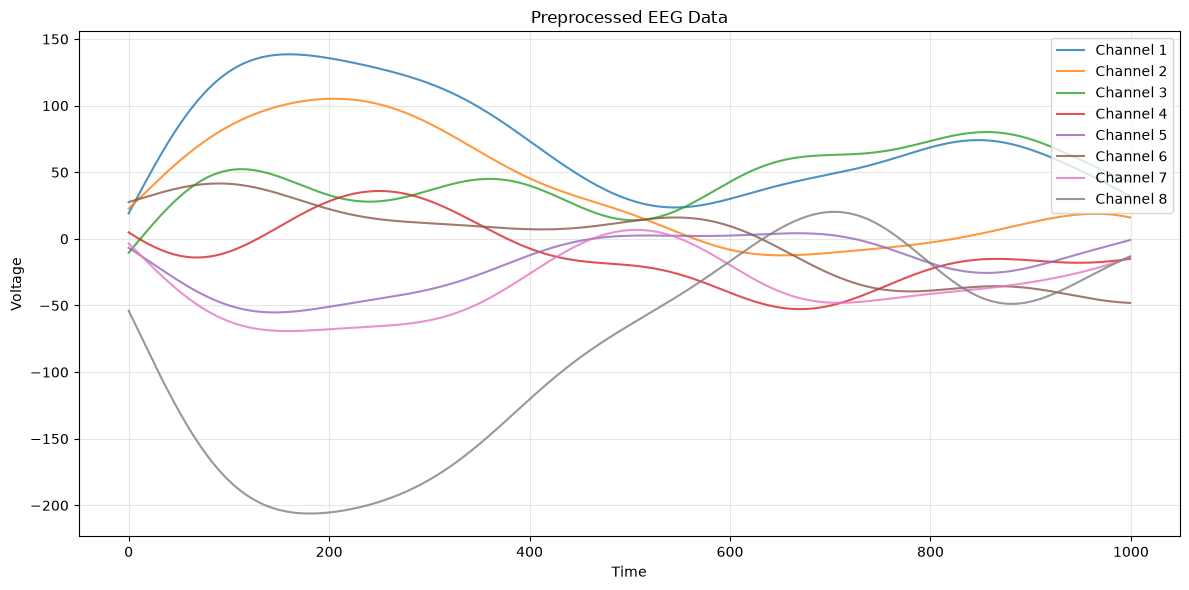

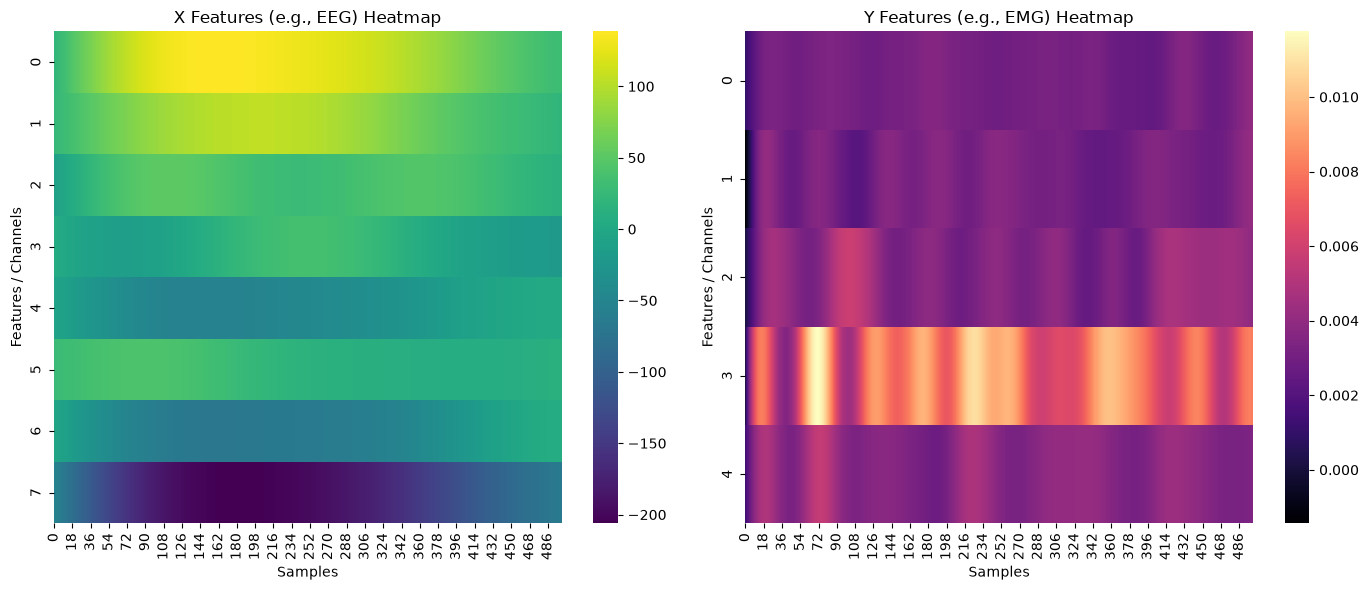

In [13]:
# Plot the first 1000 samples of the first EEG recording
plot_time_series(eeg_sample[:1000], title="Preprocessed EEG Data", ylabel="Voltage")

# Plot feature heatmaps for the first 500 samples
plot_feature_heatmaps(eeg_sample[:500], emg_sample[:500])

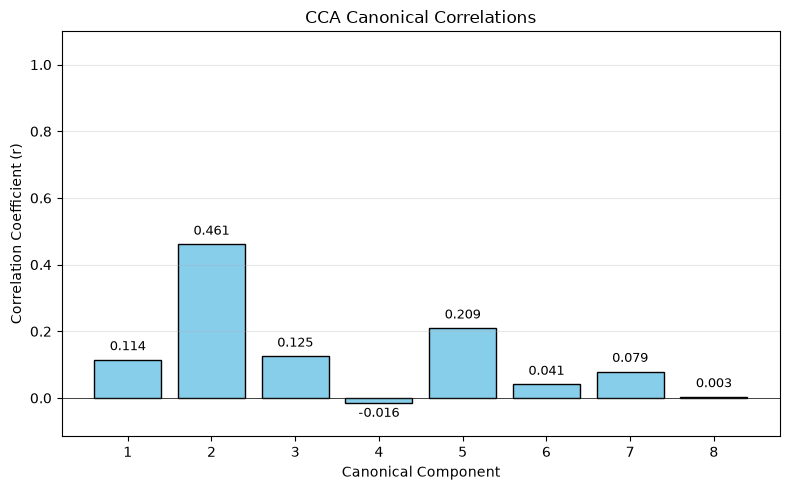

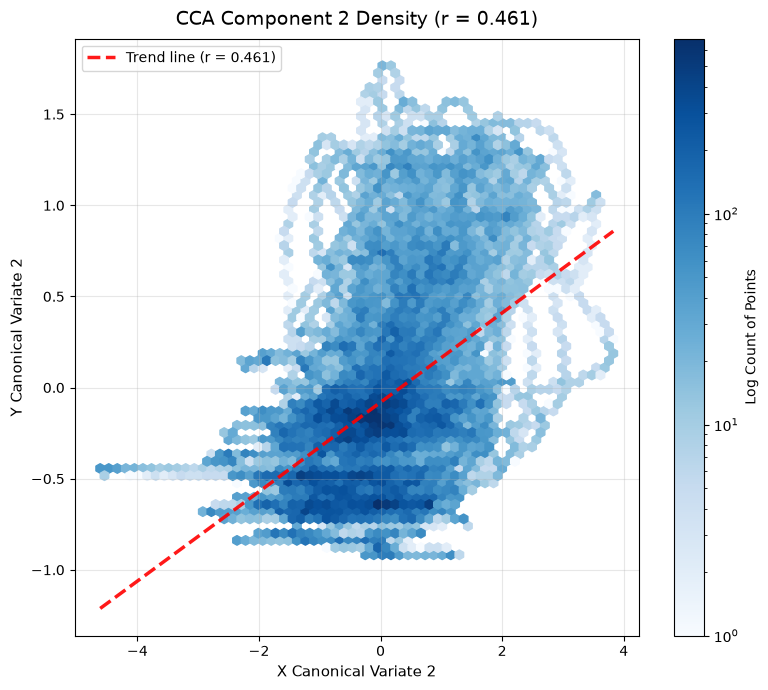

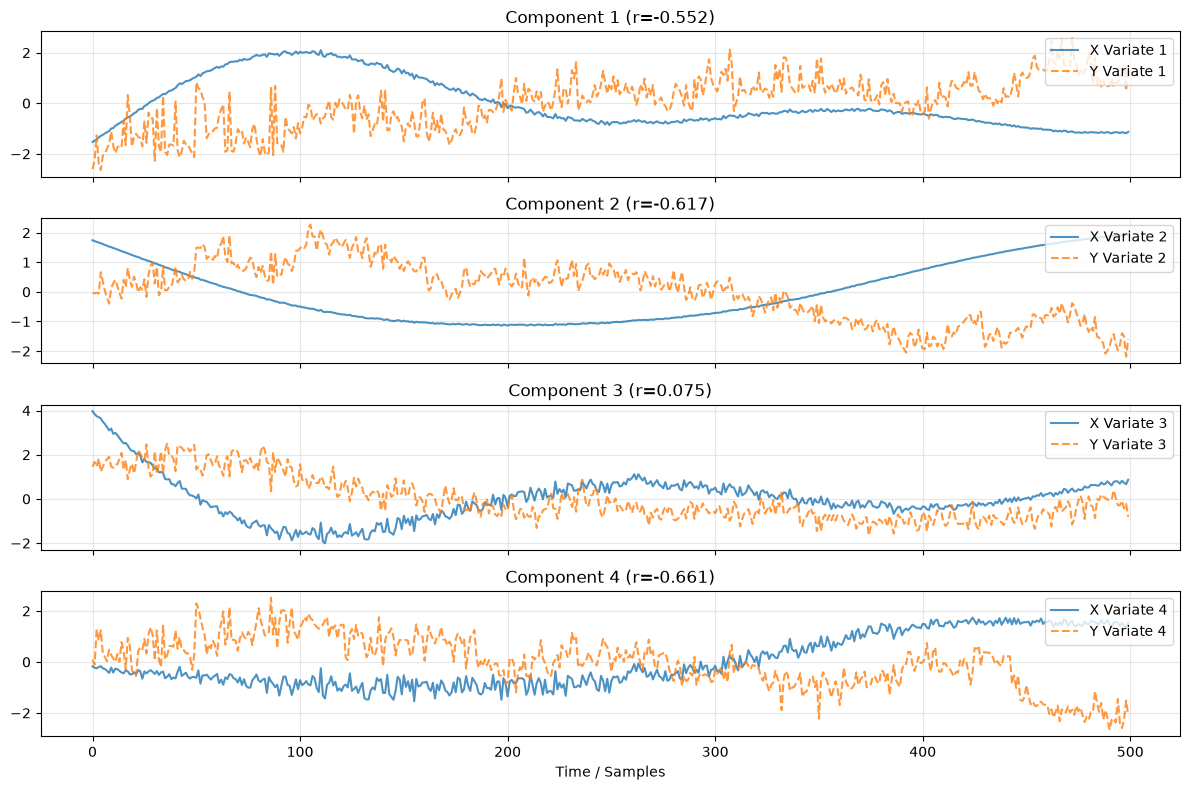

In [14]:
# View the correlation coefficients for all components
plot_cca_correlations(correlations)

# View a scatter plot of the highest correlated component (Component 1, idx=0)
plot_cca_scatter(X_c, Y_c, component_idx=1)

# View the time series of the first 3 components to see how well they track each other
plot_cca_components_timeseries(X_c[:500], Y_c[:500], num_components=4)


## 5. Model: Transformer encoder + linear readout head

`H_temp (B,T,256)` → `Linear(256→5)` per time step. The head is a placeholder for the kinematic-guided GAT + decoder.

In [15]:
# @title TransformerRegressor
model = build_transformer_regressor(cfg, input_dim=N_CCA).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print('trainable params:', n_params)


TransformerRegressor(
  (encoder): TransformerEncoder(
    (embed): Linear(in_features=8, out_features=64, bias=True)
    (pos_enc): SinusoidalPositionalEncoding(
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (mhsa): MultiHeadSelfAttention(
          (W_Q): Linear(in_features=64, out_features=256, bias=False)
          (W_K): Linear(in_features=64, out_features=256, bias=False)
          (W_V): Linear(in_features=64, out_features=256, bias=False)
          (W_O): Linear(in_features=256, out_features=64, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
        )
        (ffn): PositionwiseFeedForward(
          (fc1): Linear(in_features=64, out_features=256, bias=True)
          (fc2): Linear(in_features=256, out_features=64, bias=True)
          (act): ReLU()
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)

### infrence

In [17]:
# @title test_untrained_inference
from torch.utils.data import DataLoader
import torch

def test_untrained_inference():
    print(f"Using device: {DEVICE}")
    model.eval()
    batch_size = 16
    print(f"Fetching a batch of size {batch_size} from train_ds...")
    
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    eeg_batch, kin_batch, emg_batch = next(iter(loader))
    print("Preparing batch (CCA projection & EMG normalization)...")
    
    # FIX 2: Passed kin_batch to prepare_batch. 
    # Renamed cca_eeg to model_inputs since it's a dict
    model_inputs, emg_norm = prepare_batch(eeg_batch, kin_batch, emg_batch)
    
    # FIX 3: Accessed the "eeg" key to get the tensor and its shape
    print(f"Model input shape (CCA EEG): {model_inputs['eeg'].shape}")
    print("Running forward pass...")
    with torch.no_grad():
        # Passed the tensor into the model (assuming model expects the tensor directly)
        predictions = model(model_inputs["eeg"])
        
    print(f"Success! Output tensor shape: {predictions.shape}")
    print(f"Target EMG shape: {emg_norm.shape}")
    return predictions, emg_norm

if __name__ == "__main__":
    preds, targets = test_untrained_inference()


Using device: cuda
Fetching a batch of size 16 from train_ds...
Preparing batch (CCA projection & EMG normalization)...
Model input shape (CCA EEG): torch.Size([16, 250, 8])
Running forward pass...
Success! Output tensor shape: torch.Size([16, 250, 5])
Target EMG shape: torch.Size([16, 250, 5])


## 6. Training

Adam (lr 1e-3, halve on val plateau), MSE loss, grad-clip 1.0, early stopping. `MAX_EPOCHS` kept small for a runnable demo; raise toward `cfg['training']['max_epochs']` (500) for a full run.

In [18]:
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s', force=True)

tr_cfg = cfg['training']
BATCH  = tr_cfg['batch_size']

# -- Checkpoint directory (crash-safe: last.pt written every epoch) -----------
CKPT_DIR = str(ROOT / 'outputs' / 'checkpoints')

# -- DataLoaders --------------------------------------------------------------
loader_cfg = cfg.get('runtime', {})
loader_kw = {}
if DEVICE.type == 'cuda':
    loader_kw['pin_memory'] = loader_cfg.get('pin_memory', True)
    loader_kw['num_workers'] = loader_cfg.get('num_workers', 2)
    if loader_kw['num_workers'] > 0:
        loader_kw['persistent_workers'] = loader_cfg.get('persistent_workers', True)
        loader_kw['prefetch_factor'] = loader_cfg.get('prefetch_factor', 2)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True, **loader_kw)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, **loader_kw)

# -- Loss & TrainConfig -------------------------------------------------------
loss_fn = build_loss_from_config(tr_cfg).to(DEVICE)

# MAX_EPOCHS: set to None to use config value (500).
# Set to a small number (e.g. 15) for a quick smoke-test.
MAX_EPOCHS = 20  # <- change to e.g. 15 for a short demo run

train_config = TrainConfig.from_config(tr_cfg, max_epochs=MAX_EPOCHS)
train_config.checkpoint_dir   = CKPT_DIR
train_config.checkpoint_every = 1   # save last.pt every epoch

# -- Train -------------------------------------------------------------------
# resume=True (default): if outputs/checkpoints/last.pt exists the loop
# picks up from where it left off automatically after a crash or interrupt.
# Set resume=False to force a completely fresh run (ignores any existing last.pt).
result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=DEVICE,
    cfg=train_config,
    resume=False,
)

hist = result.history
print('Best val loss:', round(result.best_val, 4))

# -- Export lightweight inference checkpoint ----------------------------------
# train_model already wrote last.pt / best.pt to CKPT_DIR automatically.
# This exports a separate slim file (weights + metadata only, no optimizer)
# that is safe to ship for inference.
inference_ckpt = str(ROOT / 'outputs' / 'transformer_best.pt')
save_checkpoint(inference_ckpt, model, train_config, result.best_val)
print('Resumable checkpoints :', CKPT_DIR)
print('Inference checkpoint   :', inference_ckpt)


Training on cuda | AMP=True | epochs=20 | lr=0.0001 | ckpt_dir=d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints


  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 11.1 MB
  OK  VRAM reserved   : 112.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active

Starting fresh training run  (checkpoint_dir=d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints)



  Ep    1 [train]:   0%|          | 0/5103 [00:07<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/477 [00:05<?, ?batch/s]

Ep    1/20 | train 0.9799 | val 0.7930 | lr 1.00e-04 | 395.5s | VRAM 22/6144 MB  <- BEST


...

Ep   19/20 | train 0.8557 | val 0.8038 | lr 1.00e-04 | 382.2s | VRAM 22/6144 MB


  Ep   20 [train]:   0%|          | 0/5103 [00:00<?, ?batch/s]

  Ep   20 [val  ]:   0%|          | 0/477 [00:00<?, ?batch/s]

Ep   20/20 | train 0.8536 | val 0.8169 | lr 1.00e-04 | 382.4s | VRAM 22/6144 MB
checkpoint saved -> d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\transformer_best.pt


Ep   20/20 | train 0.8536 | val 0.8169 | lr 1.00e-04 | 382.4s | VRAM 22/6144 MB

Training done.  Best val loss = 0.7607
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints
Best val loss: 0.7607
Saved inference checkpoint -> d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\transformer_best.pt
Resumable checkpoints : d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints
Inference checkpoint   : d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\transformer_best.pt


## 7. Loss curve

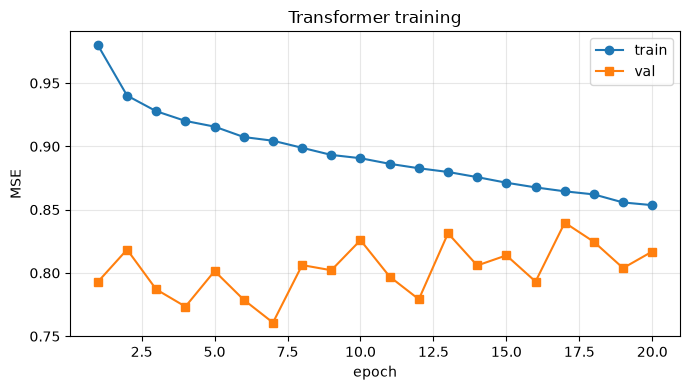

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(hist['train'])+1), hist['train'], 'o-', label='train')
plt.plot(range(1, len(hist['val'])+1),   hist['val'],   's-', label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.title('Transformer training')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Predicted vs target EMG on a test window

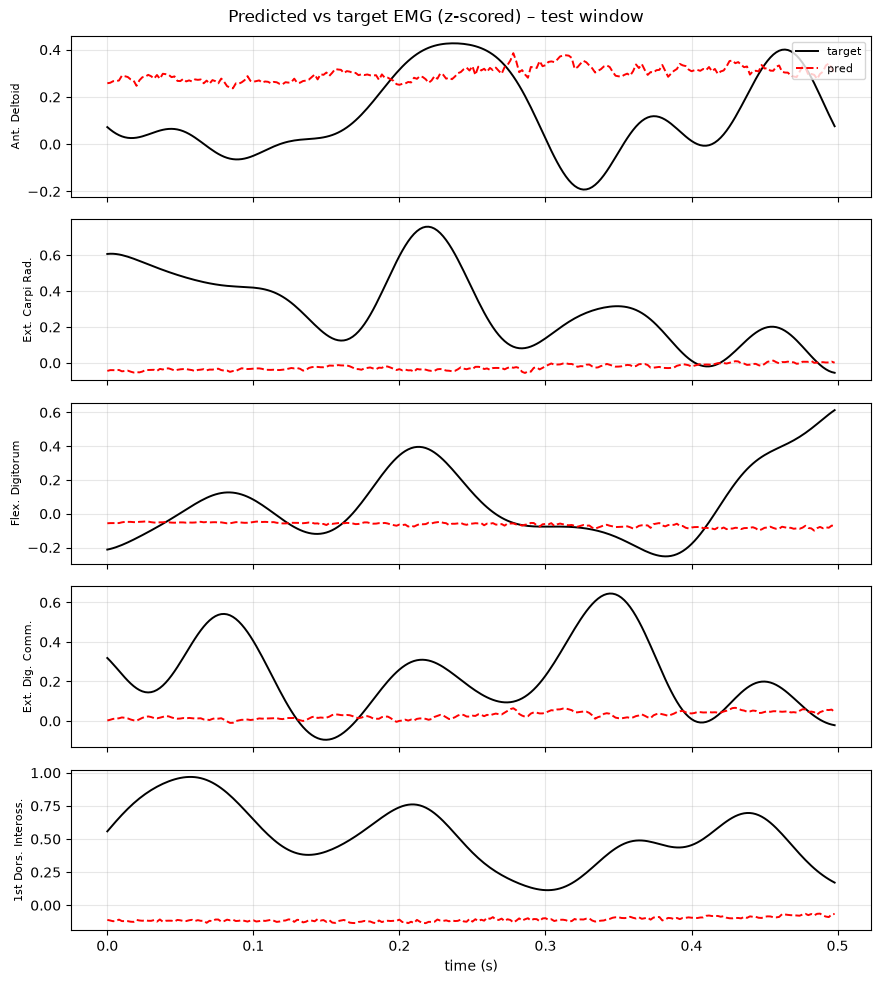

In [23]:
EMG_NAMES = ['Ant. Deltoid', 'Ext. Carpi Rad.', 'Flex. Digitorum', 'Ext. Dig. Comm.', '1st Dors. Inteross.']

model.eval()
eeg, kin, emg = test_ds[len(test_ds)//2]
x, y = prepare_batch(eeg.unsqueeze(0), kin.unsqueeze(0), emg.unsqueeze(0))

with torch.no_grad():
    # Fix: Unpack the dictionary 'x' with ** so 'eeg' and 'kin' are passed as keyword arguments
    pred = model(**x)[0].cpu().numpy()
y = y[0].cpu().numpy()

t = np.arange(W) / cfg['data']['fs_eeg']
fig, axes = plt.subplots(5, 1, figsize=(9, 10), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(t, y[:, c],   'k-',  lw=1.4, label='target')
    ax.plot(t, pred[:, c], 'r--', lw=1.4, label='pred')
    ax.set_ylabel(EMG_NAMES[c], fontsize=8)
    ax.grid(alpha=0.3)
    if c == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('time (s)')
fig.suptitle('Predicted vs target EMG (z-scored) – test window')
plt.tight_layout(); plt.show()


## 9. Test metrics (per channel)

RMSE, MAE, Pearson r on z-scored EMG over the full test split.

In [22]:
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, **loader_kw)
metrics = evaluate(
    model=model,
    loader=test_loader,
    prepare_batch=prepare_batch,
    device=DEVICE,
    channel_names=EMG_NAMES,
    n_channels=5,
)
print(metrics.as_table())

evaluation complete:
channel                  RMSE      MAE  Pearson
Ant. Deltoid            1.054    0.812    0.330
Ext. Carpi Rad.         0.925    0.589    0.355
Flex. Digitorum         0.998    0.583    0.320
Ext. Dig. Comm.         0.614    0.461    0.400
1st Dors. Inteross.     1.018    0.603    0.281
MEAN                    0.922    0.610    0.337


channel                  RMSE      MAE  Pearson
Ant. Deltoid            1.054    0.812    0.330
Ext. Carpi Rad.         0.925    0.589    0.355
Flex. Digitorum         0.998    0.583    0.320
Ext. Dig. Comm.         0.614    0.461    0.400
1st Dors. Inteross.     1.018    0.603    0.281
MEAN                    0.922    0.610    0.337
